# Problema 10.3(ii): integración pseudoespectral

Resolvemos numéricamente la ecuación de Kuramoto–Sivashinsky reescalada en el dominio periódico
$$
0\leq x<2\pi,
$$
$$
\frac{\partial u}{\partial t}
=-\frac{\partial^2u}{\partial x^2}
-k^2\frac{\partial^4u}{\partial x^4}
-u\frac{\partial u}{\partial x},
$$
con condición inicial
$$
u(0,x)=-\sin(x)
$$
y para
$$
\frac{1}{k}=\frac{L}{2\pi}=0.8,\;1.2,\;1.94.
$$

Finalmente extraemos las amplitudes `a_1` y `a_2` de la solución completa y las comparamos con el truncamiento de Galerkin a dos modos del inciso 10.3(i).

## Observación sobre el signo inicial

En el inciso 10.3(i) se pidió
$$
(a_1(0),a_2(0))=(1,0),
$$
mientras que la condición inicial de este inciso implica
$$
(a_1(0),a_2(0))=(-1,0).
$$
Para realizar una comparación directa, integraremos el sistema de dos modos con `a_1(0)=-1`. El sistema es simétrico ante
$$
a_1\longrightarrow-a_1,
\qquad
a_2\longrightarrow a_2,
$$
por lo que esto solamente refleja respecto del eje `a_2` la trayectoria obtenida en el inciso anterior.


## Formulación pseudoespectral

Usamos la identidad
$$
u\,u_x=\frac{1}{2}\frac{\partial}{\partial x}(u^2).
$$
Si `q` denota un número de onda entero, la transformada de Fourier de la ecuación satisface
$$
\frac{d\widehat u_q}{dt}
=\underbrace{\left(q^2-k^2q^4\right)\widehat u_q}_{\text{parte lineal}}
-\underbrace{\frac{iq}{2}\widehat{u^2}_q}_{\text{parte no lineal}}.
$$

El método alterna entre ambos espacios:

1. Los coeficientes `u_hat` representan el campo en Fourier.
2. Una FFT inversa reconstruye `u(x)`.
3. El producto `u^2` se calcula en espacio físico.
4. Una FFT devuelve el producto al espacio espectral.
5. Los modos altos del producto se eliminan mediante la regla de los dos tercios.

La cuarta derivada vuelve rígida la parte lineal. En lugar de tratarla mediante un RK explícito —que exigiría un paso extremadamente pequeño— usamos ETDRK4. Este método integra exactamente el operador lineal durante cada paso y aplica un esquema tipo Runge–Kutta de cuarto orden al término no lineal.

Tomaremos
$$
N_x=64,
\qquad
\Delta t=10^{-2},
\qquad
t_f=4.
$$
Después repetiremos el cálculo con el doble de resolución y la mitad del paso para comprobar convergencia.


In [1]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({"figure.dpi": 120})


## Sistema de referencia con dos modos

Para comparar con la PDE completa integramos nuevamente
$$
\dot a_1=(1-k^2)a_1+\frac{1}{2}a_1a_2,
$$
$$
\dot a_2=4(1-4k^2)a_2-\frac{1}{2}a_1^2,
$$
pero ahora usando la condición inicial correspondiente a `-sin(x)`.


In [2]:
def rhs_dos_modos(a, inverso_k):
    a1, a2 = a
    k = 1.0 / inverso_k
    return np.array([
        (1.0 - k**2) * a1 + 0.5 * a1 * a2,
        4.0 * (1.0 - 4.0 * k**2) * a2 - 0.5 * a1**2,
    ])


def integrar_modal(inverso_k, tf=4.0, dt=1e-3, a0=(-1.0, 0.0)):
    n_steps = int(np.ceil(tf / dt))
    dt = tf / n_steps
    t = np.linspace(0.0, tf, n_steps + 1)
    a = np.empty((n_steps + 1, 2))
    a[0] = a0

    for n in range(n_steps):
        an = a[n]
        k1 = rhs_dos_modos(an, inverso_k)
        k2 = rhs_dos_modos(an + 0.5*dt*k1, inverso_k)
        k3 = rhs_dos_modos(an + 0.5*dt*k2, inverso_k)
        k4 = rhs_dos_modos(an + dt*k3, inverso_k)
        a[n + 1] = an + dt*(k1 + 2*k2 + 2*k3 + k4)/6.0

    return t, a


## Integrador de la PDE

La máscara de de-aliasing conserva solamente los modos que cumplen
$$
|q|\leq\frac{N_x}{3}.
$$
Esto evita que los armónicos altos generados por el producto cuadrático reaparezcan falsamente como modos bajos.

Con la convención usada por `numpy.fft`, las amplitudes de la expansión
$$
u(x,t)=\sum_{n=1}^{\infty}a_n(t)\sin(nx)
$$
se recuperan mediante
$$
a_n(t)=-\frac{2}{N_x}\operatorname{Im}\left(\widehat u_n(t)\right).
$$


In [3]:
def coeficientes_etdrk4(lineal, dt, M=32):
    E = np.exp(dt * lineal)
    E2 = np.exp(0.5 * dt * lineal)
    raices = np.exp(1j*np.pi*(np.arange(1, M + 1) - 0.5)/M)
    LR = dt*lineal[:, None] + raices[None, :]

    Q = dt*np.real(np.mean((np.exp(LR/2.0) - 1.0)/LR, axis=1))
    f1 = dt*np.real(np.mean(
        (-4.0 - LR + np.exp(LR)*(4.0 - 3.0*LR + LR**2))/LR**3,
        axis=1,
    ))
    f2 = dt*np.real(np.mean(
        (2.0 + LR + np.exp(LR)*(-2.0 + LR))/LR**3,
        axis=1,
    ))
    f3 = dt*np.real(np.mean(
        (-4.0 - 3.0*LR - LR**2 + np.exp(LR)*(4.0 - LR))/LR**3,
        axis=1,
    ))
    return E, E2, Q, f1, f2, f3


def integrar_pseudoespectral(inverso_k, Nx=64, tf=4.0, dt=1e-2):
    k = 1.0 / inverso_k
    x = 2.0*np.pi*np.arange(Nx)/Nx
    modos = np.fft.fftfreq(Nx, d=1.0/Nx)
    lineal = modos**2 - k**2*modos**4
    mascara = np.abs(modos) <= Nx/3.0

    n_steps = int(np.ceil(tf/dt))
    dt = tf/n_steps
    t = np.linspace(0.0, tf, n_steps + 1)
    E, E2, Q, f1, f2, f3 = coeficientes_etdrk4(lineal, dt)

    def no_lineal(v):
        u = np.fft.ifft(v).real
        cuadrado_fft = np.fft.fft(u*u)
        cuadrado_fft[~mascara] = 0.0
        return -0.5j*modos*cuadrado_fft

    v = np.fft.fft(-np.sin(x))
    historia = np.empty((n_steps + 1, Nx), dtype=np.complex128)
    historia[0] = v

    for n in range(n_steps):
        Nv = no_lineal(v)
        a = E2*v + Q*Nv
        Na = no_lineal(a)
        b = E2*v + Q*Na
        Nb = no_lineal(b)
        c = E2*a + Q*(2.0*Nb - Nv)
        Nc = no_lineal(c)
        v = E*v + f1*Nv + 2.0*f2*(Na + Nb) + f3*Nc
        v[0] = 0.0
        historia[n + 1] = v

    u = np.fft.ifft(historia, axis=1).real
    return t, x, u, historia


def extraer_amplitudes_seno(historia_fft, cantidad=2):
    Nx = historia_fft.shape[1]
    return -2.0*historia_fft[:, 1:cantidad + 1].imag/Nx


In [4]:
valores_inverso_k = (0.8, 1.2, 1.94)
resultados = {}

print("Comparación en t=4: pseudoespectral vs. truncamiento de dos modos")
print(" 1/k   a1_PDE       a2_PDE       a1_2modos    a2_2modos")

for inverso_k in valores_inverso_k:
    t, x, u, historia_fft = integrar_pseudoespectral(inverso_k)
    amplitudes = extraer_amplitudes_seno(historia_fft)
    tm, modal = integrar_modal(inverso_k)
    resultados[inverso_k] = (t, x, u, amplitudes, tm, modal)
    print(
        f"{inverso_k:4.2f}  {amplitudes[-1,0]: .9f}  {amplitudes[-1,1]: .9f}  "
        f"{modal[-1,0]: .9f}  {modal[-1,1]: .9f}"
    )


Comparación en t=4: pseudoespectral vs. truncamiento de dos modos
 1/k   a1_PDE       a2_PDE       a1_2modos    a2_2modos
0.80  -0.104313550  -0.000273746  -0.104313397  -0.000273747
1.20  -2.324320666  -0.358373189  -2.319668316  -0.365045343
1.94  -0.970326705  -1.590151136  -0.679143475  -2.239417542


## Control de convergencia

Repetimos cada simulación usando
$$
N_x=128,
\qquad
\Delta t=5\times10^{-3}.
$$
Comparamos las amplitudes finales con las obtenidas usando la resolución base. Medimos el máximo error entre `a_1` y `a_2`.


In [5]:
print(" 1/k   error_inf en (a1,a2) al t=4")
errores_convergencia = {}

for inverso_k in valores_inverso_k:
    _, _, _, historia_fina = integrar_pseudoespectral(
        inverso_k, Nx=128, dt=5e-3
    )
    amplitudes_finas = extraer_amplitudes_seno(historia_fina)[-1]
    amplitudes_base = resultados[inverso_k][3][-1]
    error = np.linalg.norm(amplitudes_finas - amplitudes_base, ord=np.inf)
    errores_convergencia[inverso_k] = error
    print(f"{inverso_k:4.2f}   {error:.3e}")


 1/k   error_inf en (a1,a2) al t=4
0.80   1.243e-10
1.20   3.474e-09
1.94   3.679e-08


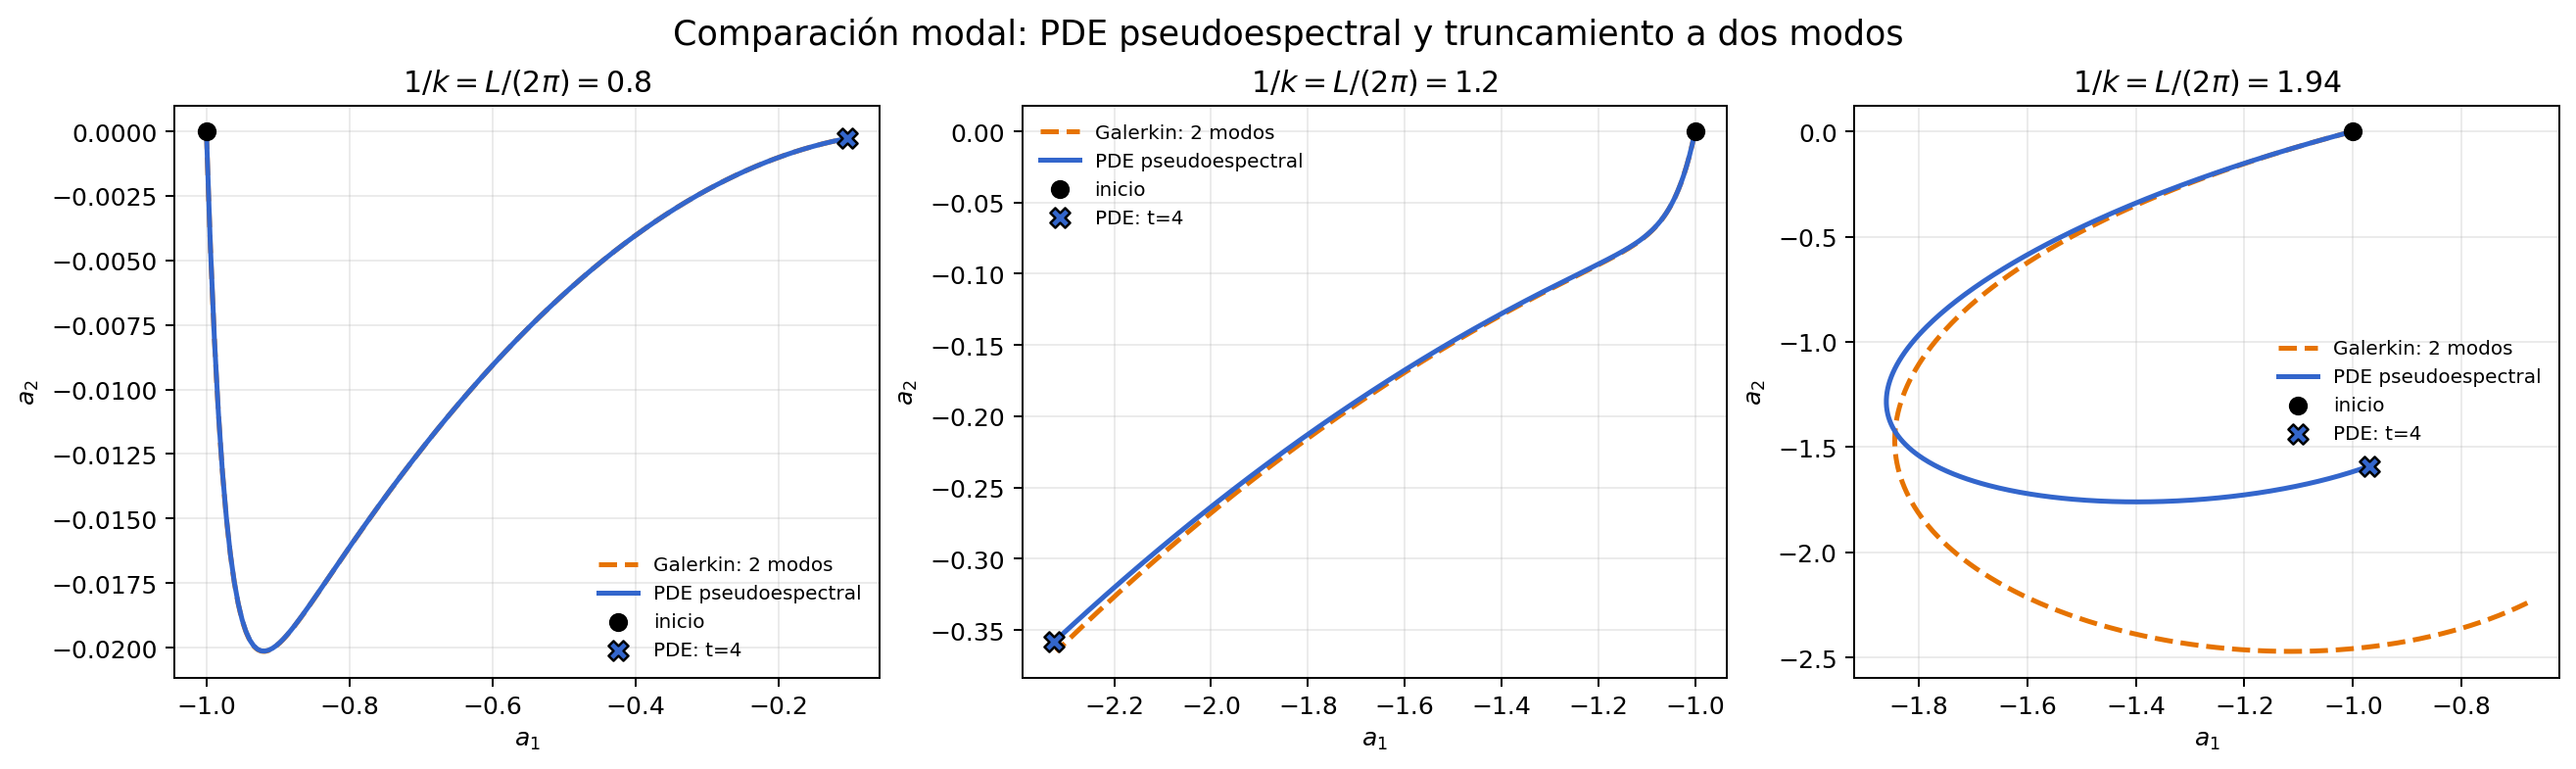

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(14.5, 4.25), constrained_layout=True)

for ax, inverso_k in zip(axes, valores_inverso_k):
    _, _, _, amplitudes, _, modal = resultados[inverso_k]
    ax.plot(modal[:, 0], modal[:, 1], "--", color="#E67300", lw=2,
            label="Galerkin: 2 modos")
    ax.plot(amplitudes[:, 0], amplitudes[:, 1], color="#3366CC", lw=2,
            label="PDE pseudoespectral")
    ax.scatter(-1.0, 0.0, color="black", s=45, zorder=4, label="inicio")
    ax.scatter(*amplitudes[-1], color="#3366CC", edgecolor="black",
               marker="X", s=65, zorder=4, label="PDE: t=4")
    ax.set_title(rf"$1/k=L/(2\pi)={inverso_k}$")
    ax.set_xlabel(r"$a_1$")
    ax.set_ylabel(r"$a_2$")
    ax.grid(alpha=0.25)
    ax.legend(frameon=False, fontsize=8)

fig.suptitle("Comparación modal: PDE pseudoespectral y truncamiento a dos modos", fontsize=14)
plt.show()


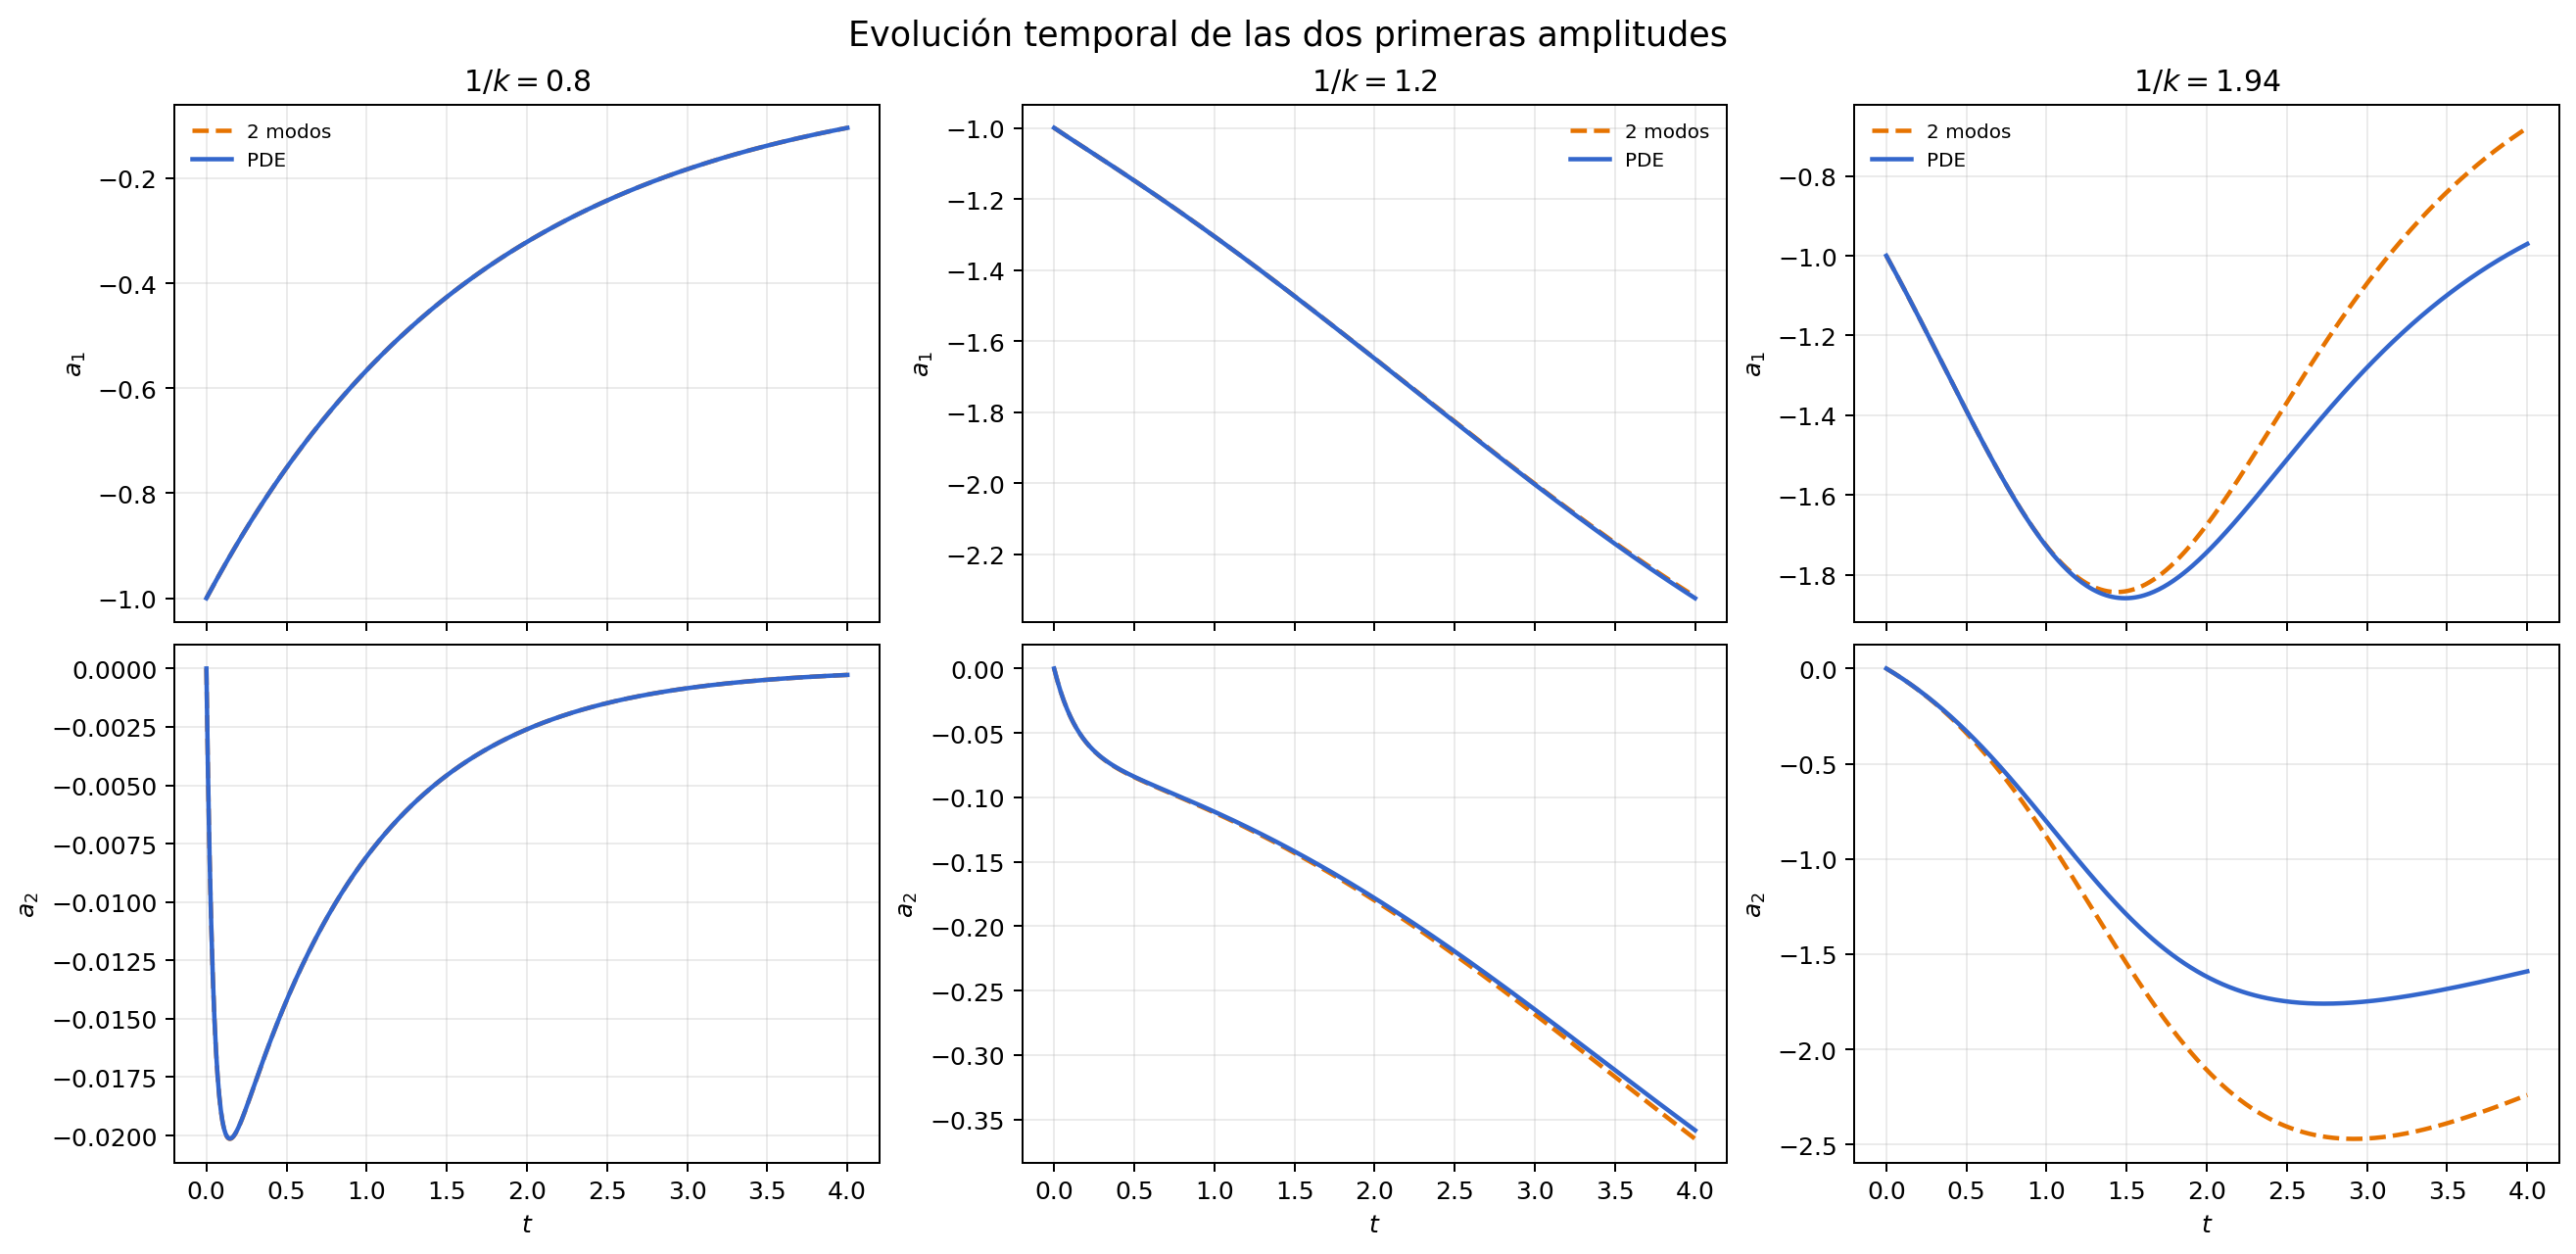

In [7]:
fig, axes = plt.subplots(2, 3, figsize=(14.5, 7.0), sharex="col", constrained_layout=True)

for j, inverso_k in enumerate(valores_inverso_k):
    t, _, _, amplitudes, tm, modal = resultados[inverso_k]
    for i, etiqueta in enumerate((r"$a_1$", r"$a_2$")):
        axes[i, j].plot(tm, modal[:, i], "--", color="#E67300", lw=1.8,
                        label="2 modos")
        axes[i, j].plot(t, amplitudes[:, i], color="#3366CC", lw=1.8,
                        label="PDE")
        axes[i, j].set_ylabel(etiqueta)
        axes[i, j].grid(alpha=0.25)
    axes[0, j].set_title(rf"$1/k={inverso_k}$")
    axes[1, j].set_xlabel(r"$t$")
    axes[0, j].legend(frameon=False, fontsize=8)

fig.suptitle("Evolución temporal de las dos primeras amplitudes", fontsize=14)
plt.show()


## Comparación de resultados

### Caso `1/k = 0.8`

Las curvas pseudoespectral y de dos modos son prácticamente indistinguibles. El estado trivial es estable y los modos superiores generados por la no linealidad permanecen muy pequeños. En consecuencia, el truncamiento a dos modos describe correctamente la dinámica.

### Caso `1/k = 1.2`

Ambas trayectorias continúan siendo muy cercanas. Aparece una diferencia pequeña porque la PDE permite transferir amplitud hacia `a_3`, `a_4` y modos superiores, mientras que el modelo reducido fuerza esas amplitudes a cero.

### Caso `1/k = 1.94`

La diferencia es clara. Los dos modelos coinciden durante la etapa inicial, pero luego los modos superiores modifican la evolución de `a_1` y `a_2`. El truncamiento de Galerkin a dos modos ya no representa cuantitativamente la PDE completa para este tamaño de dominio.

Los errores de refinamiento son menores que
$$
4\times10^{-8},
$$
de modo que la separación observada en el último caso no es un artefacto de la grilla o del paso temporal: es el efecto físico de los modos omitidos por el truncamiento.
